In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

RNG_SEED = 42


def generate_houses(n_total=2000, rich_fraction=0.4, seed=RNG_SEED):
    rng = np.random.default_rng(seed)

    n_rich = int(round(n_total * rich_fraction))
    n_poor = n_total - n_rich

    # --- Spatial coordinates ---------------------------------------------------
    # Rich neighborhood: centered at (75, 75), standard deviation 6
    rich_x = rng.normal(loc=75, scale=6, size=n_rich)
    rich_y = rng.normal(loc=75, scale=6, size=n_rich)

    # Poor neighborhood: centered at (25, 25), standard deviation 8
    poor_x = rng.normal(loc=25, scale=8, size=n_poor)
    poor_y = rng.normal(loc=25, scale=8, size=n_poor)

    # --- Square footage --------------------------------------------------------
    # Rich houses: 1800–4500 square feet
    rich_sqft = rng.uniform(1800, 4500, size=n_rich)

    # Poor houses: 800–2000 square feet
    poor_sqft = rng.uniform(800, 2000, size=n_poor)

    # --- Build per-row records and stack --------------------------------------
    rich = pd.DataFrame({
        "x": rich_x,
        "y": rich_y,
        "sqft": rich_sqft,
        "neighborhood": "rich",
    })

    poor = pd.DataFrame({
        "x": poor_x,
        "y": poor_y,
        "sqft": poor_sqft,
        "neighborhood": "poor",
    })

    df = pd.concat([rich, poor], ignore_index=True)

    # --- Bedrooms and bathrooms ------------------------------------------------
    bedroom_noise = rng.normal(0, 0.3, size=len(df))

    df["num_bedrooms"] = np.clip(
        np.round(df["sqft"] / 600 + bedroom_noise),
        1,
        6
    ).astype(int)

    bathroom_noise = rng.normal(0, 0.4, size=len(df))

    df["num_bathrooms"] = np.clip(
        np.round(df["num_bedrooms"] / 1.5 + bathroom_noise),
        1,
        5
    ).astype(int)

    # --- Price -----------------------------------------------------------------
    noise_rich = rng.normal(0, 75000, size=len(df))
    noise_poor = rng.normal(0, 30000, size=len(df))

    price_rich = (
        200000
        + 300 * df["sqft"]
        + 50000 * df["num_bedrooms"]
        + 80000 * df["num_bathrooms"]
        + noise_rich
    )

    price_poor = (
        50000
        + 120 * df["sqft"]
        + 20000 * df["num_bedrooms"]
        + 30000 * df["num_bathrooms"]
        + noise_poor
    )

    df["price"] = np.where(
        df["neighborhood"] == "rich",
        price_rich,
        price_poor
    )

    # Shuffle so rich and poor rows are mixed together
    df = df.sample(
        frac=1.0,
        random_state=seed
    ).reset_index(drop=True)

    return df


houses = generate_houses()

print(houses.head())
print(f"\nshape: {houses.shape}")
print(houses["neighborhood"].value_counts())

           x          y         sqft neighborhood  num_bedrooms  \
0  16.933529  15.282653  1316.271832         poor             2   
1  79.882582  71.631102  3121.269831         rich             5   
2  27.592714  21.820133  1780.867445         poor             2   
3  40.223260  25.329440  1538.276061         poor             2   
4  28.742558  16.771966  1026.734901         poor             2   

   num_bathrooms         price  
0              1  2.692836e+05  
1              3  1.599541e+06  
2              2  3.610239e+05  
3              1  3.262355e+05  
4              1  2.328150e+05  

shape: (2000, 7)
neighborhood
poor    1200
rich     800
Name: count, dtype: int64


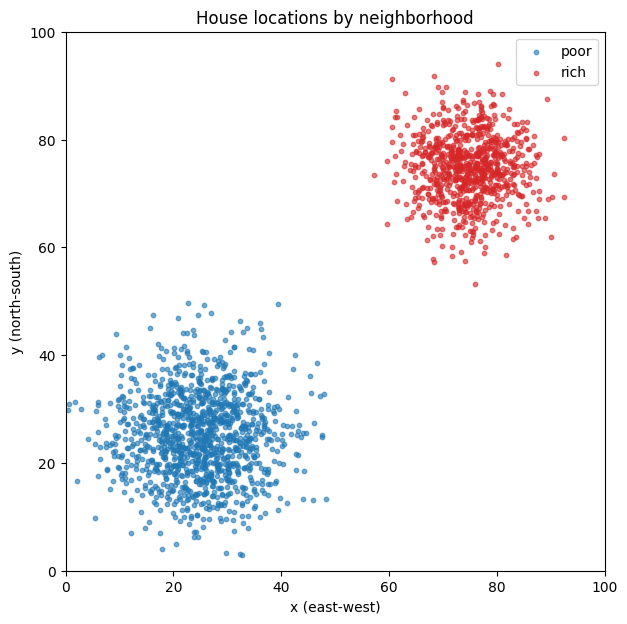

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
for color, label in [("tab:blue", "poor"), ("tab:red", "rich")]:
    subset = houses[houses["neighborhood"] == label]
    ax.scatter(subset["x"], subset["y"], s=10, alpha=0.6, label=label, color=color)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_aspect("equal")
ax.set_xlabel("x (east-west)")
ax.set_ylabel("y (north-south)")
ax.set_title("House locations by neighborhood")
ax.legend()
plt.show()

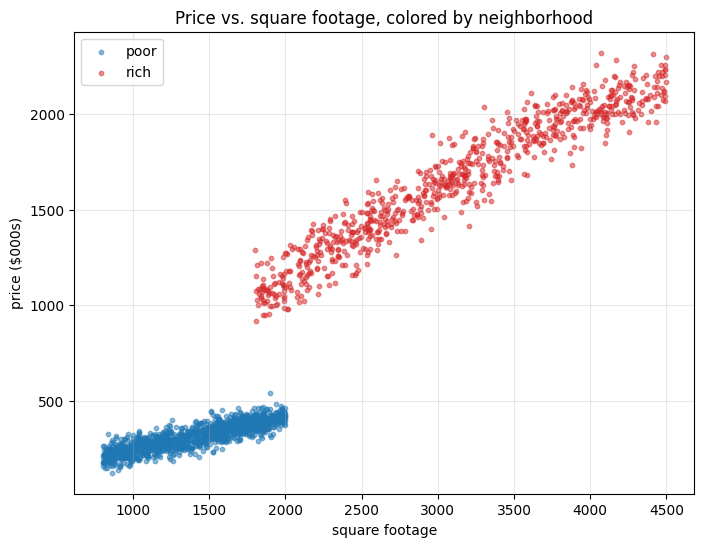

In [ ]:

fig, ax = plt.subplots(figsize=(8, 6))
for color, label in [("tab:blue", "poor"), ("tab:red", "rich")]:
    subset = houses[houses["neighborhood"] == label]
    ax.scatter(subset["sqft"], subset["price"] / 1000, s=10, alpha=0.5, label=label, color=color)
ax.set_xlabel("square footage")
ax.set_ylabel("price ($000s)")
ax.set_title("Price vs. square footage, colored by neighborhood")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


In [ ]:
FEATURES = ["x", "y", "sqft", "num_bedrooms", "num_bathrooms"]

X = houses[FEATURES].to_numpy()
y = houses["price"].to_numpy()
neigh = houses["neighborhood"].to_numpy()

X_train, X_test, y_train, y_test, neigh_train, neigh_test = train_test_split(
    X, y, neigh, test_size=0.25, random_state=RNG_SEED
)

global_model = LinearRegression()
global_model.fit(X_train, y_train)

y_pred = global_model.predict(X_test)
global_mse = mean_squared_error(y_test, y_pred)
global_rmse = np.sqrt(global_mse)  # RMSE is just the square root of MSE, in dollars

print(f"Global model MSE  (test): {global_mse:>18,.0f}  (dollars-squared)")
print(f"Global model RMSE (test): ${global_rmse:>15,.0f}  (dollars; sqrt of MSE)")
print()
print("Per-neighborhood test RMSE under the global model:")
for label in ["rich", "poor"]:
    mask = neigh_test == label
    rmse_label = np.sqrt(mean_squared_error(y_test[mask], y_pred[mask]))
    print(f"  {label:>4}: ${rmse_label:>10,.0f}  (n={mask.sum()})")


Global model MSE  (test):     11,000,663,177  (dollars-squared)
Global model RMSE (test): $        104,884  (dollars; sqrt of MSE)

Per-neighborhood test RMSE under the global model:
  rich: $   107,207  (n=201)
  poor: $   103,293  (n=299)


In [ ]:
per_neighborhood_models = {}
per_neighborhood_metrics = {}

for label in ["rich", "poor"]:
    train_mask = neigh_train == label
    test_mask = neigh_test == label

    model = LinearRegression()
    model.fit(X_train[train_mask], y_train[train_mask])
    y_pred_label = model.predict(X_test[test_mask])

    mse = mean_squared_error(y_test[test_mask], y_pred_label)
    rmse = np.sqrt(mse)

    per_neighborhood_models[label] = model
    per_neighborhood_metrics[label] = {"mse": mse, "rmse": rmse, "n_test": int(test_mask.sum())}

    print(f"{label:>4} model RMSE (test): ${rmse:>10,.0f}   (n={test_mask.sum()})")

# Aggregate test MSE across the two per-neighborhood models, for an apples-to-apples
# comparison with the single global model.
y_pred_per = np.empty_like(y_test, dtype=float)
for label, model in per_neighborhood_models.items():
    mask = neigh_test == label
    y_pred_per[mask] = model.predict(X_test[mask])
combined_mse = mean_squared_error(y_test, y_pred_per)
combined_rmse = np.sqrt(combined_mse)
print(f"\nCombined per-neighborhood MSE  (test): {combined_mse:>18,.0f}")
print(f"Combined per-neighborhood RMSE (test): ${combined_rmse:>15,.0f}")


rich model RMSE (test): $    76,677   (n=201)
poor model RMSE (test): $    32,096   (n=299)

Combined per-neighborhood MSE  (test):      2,979,575,083
Combined per-neighborhood RMSE (test): $         54,585


In [ ]:


is_rich = (neigh == "rich").astype(int).reshape(-1, 1)
X_aug = np.hstack([X, is_rich])

X_aug_train, X_aug_test, _, _, _, _ = train_test_split(
    X_aug, y, neigh, test_size=0.25, random_state=RNG_SEED
)
# Use the same y_train / y_test / neigh_train / neigh_test as before so the
# comparison is on identical rows.

onehot_model = LinearRegression()
onehot_model.fit(X_aug_train, y_train)

y_pred_onehot = onehot_model.predict(X_aug_test)
onehot_mse = mean_squared_error(y_test, y_pred_onehot)
onehot_rmse = np.sqrt(onehot_mse)

print(f"Global + one-hot model MSE  (test): {onehot_mse:>18,.0f}")
print(f"Global + one-hot model RMSE (test): ${onehot_rmse:>15,.0f}")
print()
print("Per-neighborhood test RMSE under the global + one-hot model:")
for label in ["rich", "poor"]:
    mask = neigh_test == label
    rmse_label = np.sqrt(mean_squared_error(y_test[mask], y_pred_onehot[mask]))
    print(f"  {label:>4}: ${rmse_label:>10,.0f}  (n={mask.sum()})")

print()
print("Coefficient on the new is_rich feature (intercept shift, in dollars):")
print(f"  w_is_rich = ${onehot_model.coef_[-1]:,.0f}")

Global + one-hot model MSE  (test):      7,564,805,263
Global + one-hot model RMSE (test): $         86,976

Per-neighborhood test RMSE under the global + one-hot model:
  rich: $   103,345  (n=201)
  poor: $    73,963  (n=299)

Coefficient on the new is_rich feature (intercept shift, in dollars):
  w_is_rich = $672,542


In [ ]:

# Build the augmented feature matrix: original 5 features + is_rich + 3 interactions.
is_rich_col = (neigh == "rich").astype(int).reshape(-1, 1)
sqft_col = houses["sqft"].to_numpy().reshape(-1, 1)
bed_col = houses["num_bedrooms"].to_numpy().reshape(-1, 1)
bath_col = houses["num_bathrooms"].to_numpy().reshape(-1, 1)

X_inter = np.hstack([
    X,                              # x, y, sqft, num_bedrooms, num_bathrooms
    is_rich_col,                    # is_rich
    is_rich_col * sqft_col,         # interaction with sqft
    is_rich_col * bed_col,          # interaction with num_bedrooms
    is_rich_col * bath_col,         # interaction with num_bathrooms
])

X_inter_train, X_inter_test, _, _, _, _ = train_test_split(
    X_inter, y, neigh, test_size=0.25, random_state=RNG_SEED
)
# Reuse y_train, y_test, neigh_train, neigh_test from earlier tasks so the
# comparison is on identical test rows.

interaction_model = LinearRegression()
interaction_model.fit(X_inter_train, y_train)

y_pred_inter = interaction_model.predict(X_inter_test)
inter_mse = mean_squared_error(y_test, y_pred_inter)
inter_rmse = np.sqrt(inter_mse)

print(f"Global + one-hot + interactions MSE  (test): {inter_mse:>18,.0f}")
print(f"Global + one-hot + interactions RMSE (test): ${inter_rmse:>15,.0f}")
print()
print("Per-neighborhood test RMSE under the interaction-augmented global model:")
for label in ["rich", "poor"]:
    mask = neigh_test == label
    rmse_label = np.sqrt(mean_squared_error(y_test[mask], y_pred_inter[mask]))
    print(f"  {label:>4}: ${rmse_label:>10,.0f}  (n={mask.sum()})")

print()
print("Coefficients on the rich-only adjustments (added on top of the base slopes):")
print(f"  Δ slope on sqft:           {interaction_model.coef_[-3]:>10,.2f}  $/sqft")
print(f"  Δ slope on num_bedrooms:   ${interaction_model.coef_[-2]:>10,.0f}")
print(f"  Δ slope on num_bathrooms:  ${interaction_model.coef_[-1]:>10,.0f}")

Global + one-hot + interactions MSE  (test):      2,947,928,513
Global + one-hot + interactions RMSE (test): $         54,295

Per-neighborhood test RMSE under the interaction-augmented global model:
  rich: $    76,163  (n=201)
  poor: $    32,095  (n=299)

Coefficients on the rich-only adjustments (added on top of the base slopes):
  Δ slope on sqft:               171.56  $/sqft
  Δ slope on num_bedrooms:   $    31,994
  Δ slope on num_bathrooms:  $    48,737


| Model                                       |           Test MSE | Test RMSE ($) |
| ------------------------------------------- | -----------------: | ------------: |
| One global linear regression                | **11,000,663,177** |   **104,884** |
| Two per-neighborhood regressions (combined) |  **2,979,575,083** |    **54,585** |
| Rich-only model on rich test rows           |  **5,879,361,929** |    **76,677** |
| Poor-only model on poor test rows           |  **1,030,153,216** |    **32,096** |

1. The two per-neighborhood regression models have the lower overall test MSE. Their combined MSE is 2, 979,575,083 compared to 11,000,663,177 for the single global model. This shows that fitting seperate moidels for each neighborhood predicts house prices much more accurately.

2. No. The global model performs worse on the rich neighborhood. The RMSE is about $107,207 for rich houses and $103,293 for poor houses. The global model averages two different pricing relationships into one, making it less accurate for both neighborhoods.

3. Although each model is trained on fewer houses, each model only has to learn the pricing relationship for one neighborhood. Since the two neighborhoods follow different price formulas, the separate models can learn the correct relationships instead of averaging them together.

4. Adding a one-hot encoded neighborhood feature will partially close the gap between the global model and the two-model approach. It allows the model to learn a different intercept for each neighborhood, but it still forces both neighborhoods to share the same slopes for square footage, bedrooms, and bathrooms.

5. If the price changed gradually across the map instead of forming two distinct neighborhoods, using two separate models would probably not work as well. Instead, I would include location features, interaction terms, or use a more flexible model that can learn a continuous relationship across the entire area.

Task 7
| Model                            |       Test MSE | Test RMSE ($) |
| -------------------------------- | -------------: | ------------: |
| Bare global linear regression    | 11,000,663,177 |       104,884 |
| Global + one-hot is_rich         |  7,564,805,263 |        86,976 |
| Two per-neighborhood regressions |  2,979,575,083 |        54,585 |

1. No. The one-hot feature only partially closed the gap. The RMSE improved from $104,884 to $86,976, but it was still much higher than the two-model approach, which achieved an RMSE of $54,585. The difference is about $32,391.

2. The is_rich feature only adds a fixed dollar amount to every rich house. It does not allow the relationship between price and square footage, bedrooms, or bathrooms to change. Since the rich and poor neighborhoods have different price-per-square-foot values and different contributions from bedrooms and bathrooms, changing only the intercept cannot fully model the data.

3. To make the global model equivalent to the two-model approach, the following interaction terms are needed
is_rich * sqft
is_rich * num_bedrooms
is_rich * num_bathrooms
These interaction terms allow the model to learn different slopes for each neighborhood.

Task 8
| Model                            |       Test MSE | Test RMSE ($) |
| -------------------------------- | -------------: | ------------: |
| Bare global linear regression    | 11,000,663,177 |       104,884 |
| Global + one-hot is_rich         |  7,564,805,263 |        86,976 |
| Two per-neighborhood regressions |  2,979,575,083 |        54,585 |
| Global + one-hot + interactions  |  2,947,928,513 |        54,295 |

1. Yes. The interaction-augmented model has an RMSE of $54,295, while the two-model approach has an RMSE of $54,585. The difference is only about $290, so they are essentially the same. This shows that a single linear regression can perform just as well as two separate models when given the appropriate interaction features.

2. Yes. The interaction terms adjust the base slopes, allowing the rich neighborhood to have different effects for square footage, bedrooms, and bathrooms. These adjusted slopes closely match those learned by the separate neighborhood models.

3. The two-model approach has 12 parameters (6 for each neighborhood: 5 coefficients and 1 intercept).

The interaction model has 11 parameters (10 coefficients and 1 intercept). It achieves nearly identical performance because it shares the coefficients for the location variables (x and y) while allowing different intercepts and slopes for the neighborhood-specific pricing features.